In [1]:
import os
import netCDF4
import numpy as np
import xarray as xr
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Plot Temperature Chain

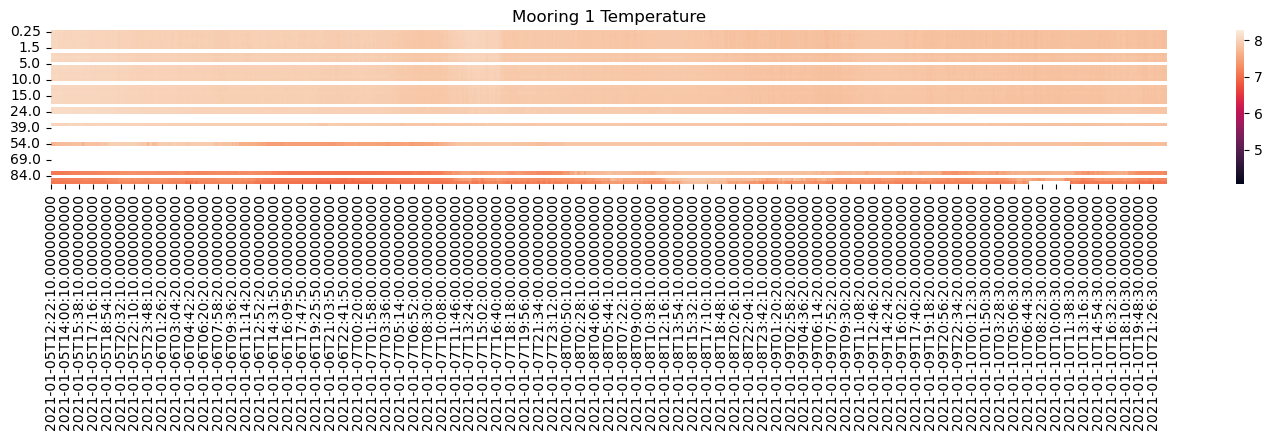

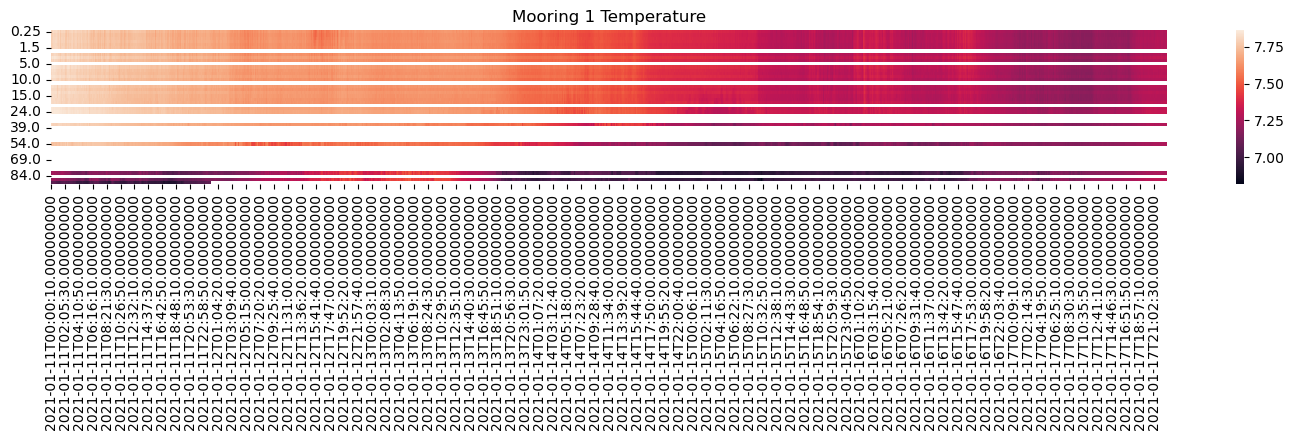

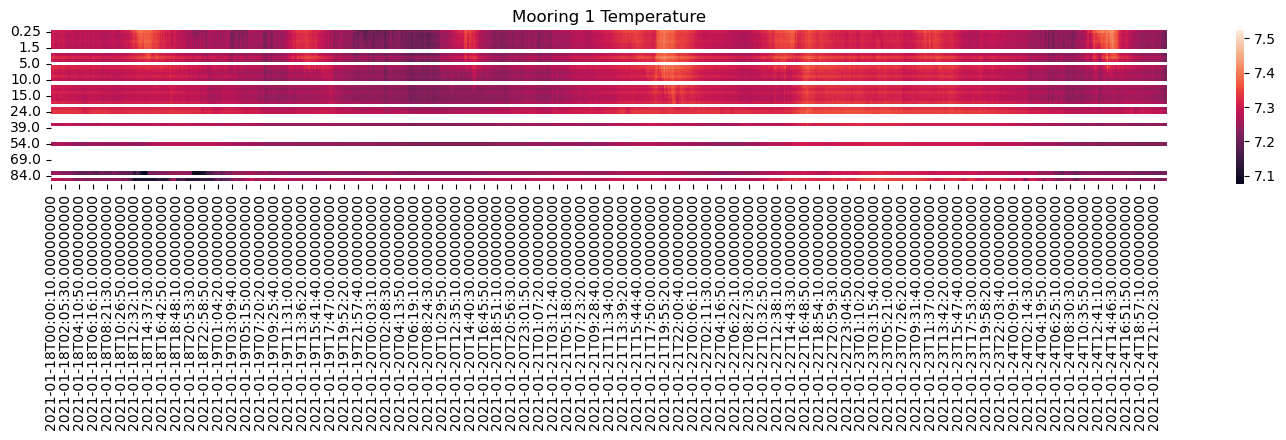

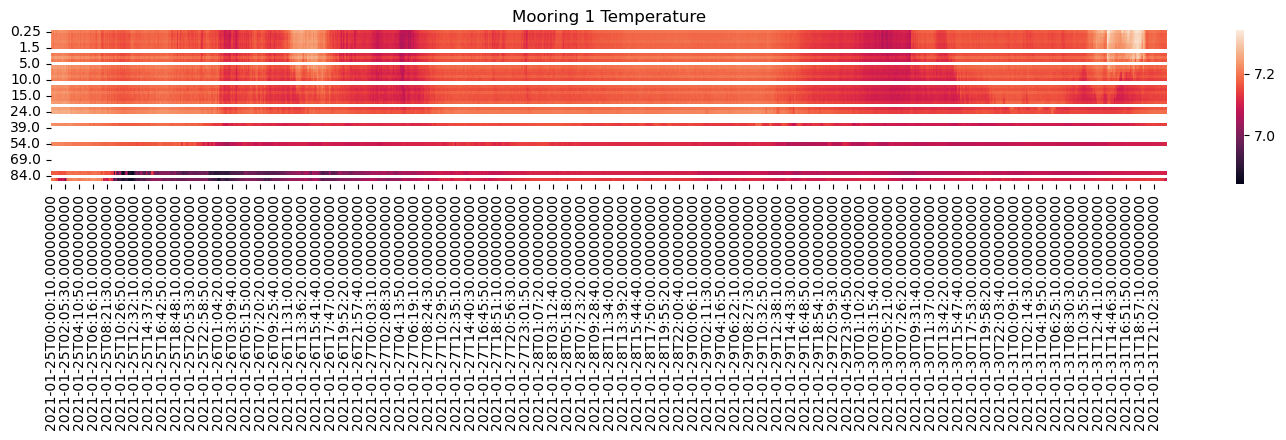

In [11]:
folder = "../data/Level1"
qa = True
files = [os.path.join(folder, f) for f in os.listdir(folder)]
files.sort()
# files = [files[-1]]
for file in files:
    if ".nc" in file and "202101" in file:
        with netCDF4.Dataset(file) as nc:
            d = np.array(nc.variables["depth"][:])
            t = np.array(nc.variables["time"][:], dtype="datetime64[s]")
            v = np.array(nc.variables["temp"][:])
            if "temp_qual" in nc.variables.keys() and qa:
                q = np.array(nc.variables["temp_qual"][:])
                v[q > 0] = np.nan
            plt.figure(figsize=(18, 2))
            plt.title("Mooring 1 Temperature")
            df = pd.DataFrame(data=v,index=d, columns=t)
            sns.heatmap(df)
            plt.show()

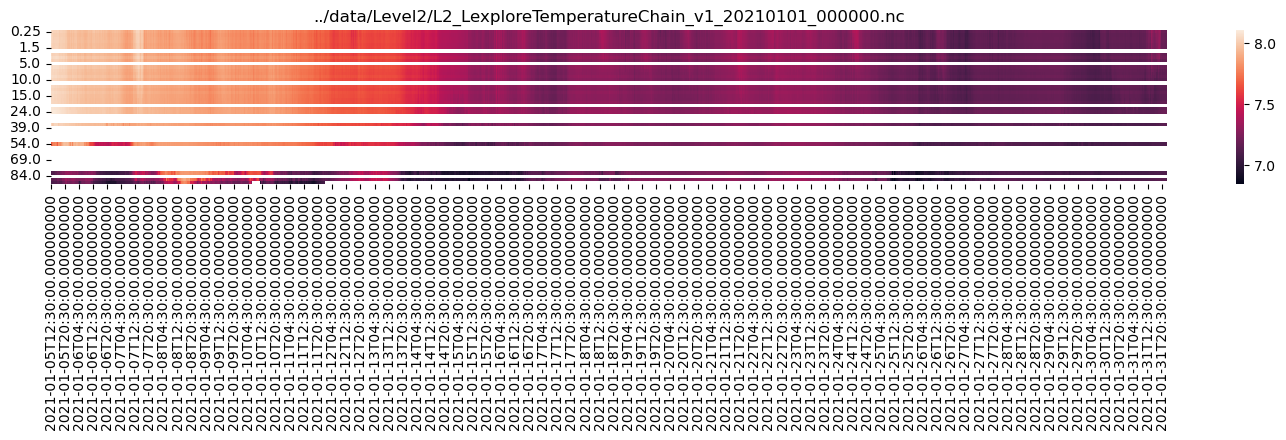

In [12]:
folder = "../data/Level2"
qa = True
files = [os.path.join(folder, f) for f in os.listdir(folder)]
files.sort()
for file in files:
    if ".nc" in file and "202101" in file:
        with netCDF4.Dataset(file) as nc:
            d = np.array(nc.variables["depth"][:])
            t = np.array(nc.variables["time"][:], dtype="datetime64[s]")
            v = np.array(nc.variables["temp"][:])
            plt.figure(figsize=(18, 2))
            plt.title(file)
            df = pd.DataFrame(data=v,index=d, columns=t)
            sns.heatmap(df)
            plt.show()

In [4]:
folder = "../data/Level2"
qa = True
files = [os.path.join(folder, f) for f in os.listdir(folder)]
files.sort()
# files = [files[-1]]
with xr.open_mfdataset(files, decode_times=False) as ds:
    t = np.array(ds.variables["time"][:].values, dtype="datetime64[s]")
    for var in ds.variables:
        if "_qual" not in var and var not in  ["depth", "time"] and len(ds.variables[var].dims) == 1:
            v = np.array(ds.variables[var][:].values)
            plt.figure(figsize=(18, 2))
            plt.title(var)
            plt.plot(t, v, label=var)
            plt.show()

OSError: no files to open

In [10]:
x = np.array([[1,2,3,4], [1,2,3,4], [1,2,3,4]])
x

array([[1, 2, 3, 4],
       [1, 2, 3, 4],
       [1, 2, 3, 4]])

In [11]:
y = np.array([False, True, True, False])

In [13]:
x[:, y]

array([[2, 3],
       [2, 3],
       [2, 3]])